### Data Acquisition-Data Preprocessing

#### Import Libraries

In [122]:
# Basic Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Preprocessing
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import MinMaxScaler

# Statistics
from scipy.stats import zscore
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway

# Feature Selection
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2

# PCA
from sklearn.decomposition import PCA

# Train Test Split
from sklearn.model_selection import train_test_split

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

##### Interpretation:
The Telecom Customer Churn dataset was loaded into the dataframe for further preprocessing and analysis.

### Load Dataset

In [123]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Basic Dataset Information

In [124]:
df.shape

(7043, 21)

In [125]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [126]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [127]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [128]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Handling Incorrect Data Type

In [129]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

##### Interpretation:
The TotalCharges column was converted from object datatype to numeric datatype to ensure proper mathematical and statistical analysis.

### Handling Missing Values

In [130]:
print(df.isnull().sum())

df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


C:\Users\Basavaraj\AppData\Local\Temp\ipykernel_24492\2084287121.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


0         29.85
1       1889.50
2        108.15
3       1840.75
4        151.65
         ...   
7038    1990.50
7039    7362.90
7040     346.45
7041     306.60
7042    6844.50
Name: TotalCharges, Length: 7043, dtype: float64

##### Interpretation:
Missing values in TotalCharges were replaced with the median value to preserve data distribution and avoid data loss.

### Removing Duplicates

In [131]:
df.duplicated().sum()

np.int64(0)

In [132]:
df.drop_duplicates(inplace=True)

##### Interpretation:
Duplicate records were removed to improve dataset quality and prevent biased analysis.

### Renaming Columns

In [133]:
df.rename(columns={
    'customerID':'Customer_ID',
    'tenure':'Tenure'
}, inplace=True)

df.head()

,Customer_ID,gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##### Interpretation:
Column names were renamed to improve readability and consistency.

### Removing Extra Spaces

In [134]:
df.columns = df.columns.str.strip()

##### Interpretation:
Extra spaces were removed from column names to avoid errors during analysis.

### Filtering Data

In [135]:
# Customers with tenure > 12
filtered_df = df[df['Tenure'] > 12]

filtered_df.head()

,Customer_ID,gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.40,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


##### Interpretation:
Customers with tenure greater than 12 months were filtered for focused analysis of long-term customers.

### Sorting Data

In [136]:
# Sort by MonthlyCharges
df.sort_values(by='MonthlyCharges', ascending=False)

,Customer_ID,gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4586,7569-NMZYQ,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),118.75,8672.45,No
2115,8984-HPEMB,Female,0,No,No,71,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,118.65,8477.60,No
4804,5734-EJKXG,Female,0,No,No,61,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Electronic check,118.60,7365.70,No
3894,5989-AXPUC,Female,0,Yes,No,68,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,No,Mailed check,118.60,7990.05,No
5127,8199-ZLLSA,Male,0,No,No,67,Yes,Yes,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Bank transfer (automatic),118.35,7804.15,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1156,0621-CXBKL,Female,0,No,No,53,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,18.70,1005.70,No
6906,9945-PSVIP,Female,0,Yes,Yes,25,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Mailed check,18.70,383.65,No
6652,0827-ITJPH,Male,0,No,No,36,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,Yes,Credit card (automatic),18.55,689.00,No
1529,9764-REAFF,Female,0,Yes,No,59,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Bank transfer (automatic),18.40,1057.85,No


##### Interpretation:
Data was sorted based on MonthlyCharges to identify customers with higher spending patterns.

### GroupBy Operations

In [137]:
# Average monthly charges by gender
group_data = df.groupby('gender')['MonthlyCharges'].mean()

print(group_data)

gender
Female    65.204243
Male      64.327482
Name: MonthlyCharges, dtype: float64


##### Interpretation:
Average monthly charges were calculated for different genders to identify spending differences.

### Pivot Table

In [138]:
pivot = pd.pivot_table(
    df,
    values='MonthlyCharges',
    index='gender',
    columns='Contract',
    aggfunc='mean'
)

print(pivot)

Contract  Month-to-month   One year   Two year
gender                                        
Female         66.652623  66.841643  60.513373
Male           66.147615  63.343444  61.025941


##### Interpretation:
A pivot table was created to summarize monthly charges based on gender and contract type.

### Skewness

In [139]:
def skewness(skew_value):
    if -0.5 <= skew_value <= 0.5:
        return "Approx Normal"
    elif (-1<= skew_value < -0.5) or (0.5<skew_value<=1):
        return"MOderate skew "
    else: 
        return "Highly skewwed"

In [140]:
numeric_cols=df.select_dtypes(include=["number"]).columns
results=[]
for col in numeric_cols:
    skew_val=df[col].skew()
    category=skewness(skew_val)
    results.append({"Column Name":col,"Skew Value":round(skew_val,3),"Skewness":category})
report=pd.DataFrame(results)
report

,Column Name,Skew Value,Skewness
0,SeniorCitizen,1.834,Highly skewwed
1,Tenure,0.240,Approx Normal
2,MonthlyCharges,-0.221,Approx Normal
3,TotalCharges,0.962,MOderate skew


##### Interpretation:
Skewness was calculated to determine whether numerical variables followed a normal distribution or were skewed.

#### Check Skewness for All Numerical Columns

In [141]:
print(df.skew(numeric_only=True))

SeniorCitizen     1.833633
Tenure            0.239540
MonthlyCharges   -0.220524
TotalCharges      0.961642
dtype: float64


#### Check Skewness for Specific Column

In [142]:
df[["MonthlyCharges","SeniorCitizen","Tenure"]].skew()

MonthlyCharges   -0.220524
SeniorCitizen     1.833633
Tenure            0.239540
dtype: float64

#### Visualize Skewness

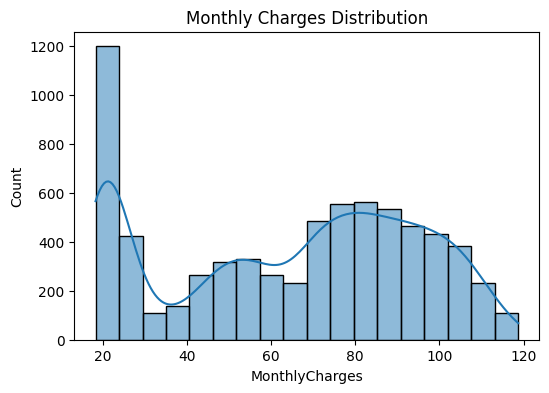

In [143]:
plt.figure(figsize=(6,4))

sns.histplot(df['MonthlyCharges'], kde=True)

plt.title("Monthly Charges Distribution")
plt.show()

#### The skewness value helps identify whether the data distribution is symmetric or skewed. If the skewness value is greater than 0, the data is positively skewed. If the skewness value is less than 0, the data is negatively skewed. A skewness value close to 0 indicates normal distribution.
| Skewness Value | Interpretation      |

| = 0            | Normal Distribution |

| > 0            | Positively Skewed   |

| < 0            | Negatively Skewed   |


In [144]:
print(df['MonthlyCharges'].describe())

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: MonthlyCharges, dtype: float64


#### Reduce Skewness Using Log Transformation

In [145]:
df['TotalCharges_log'] = np.log1p(df['TotalCharges'])

print(df['TotalCharges_log'].skew())

-0.7430886108265042


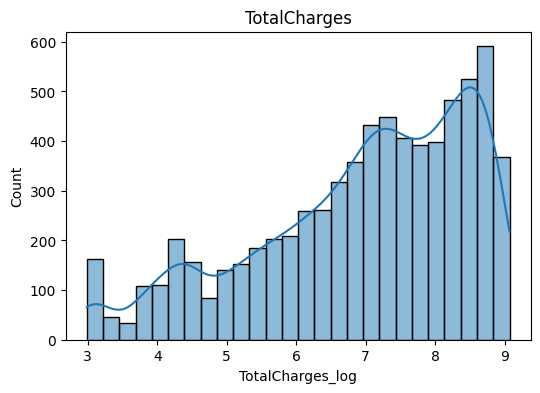

In [146]:
plt.figure(figsize=(6,4))

sns.histplot(df['TotalCharges_log'], kde=True)

plt.title("TotalCharges")
plt.show()

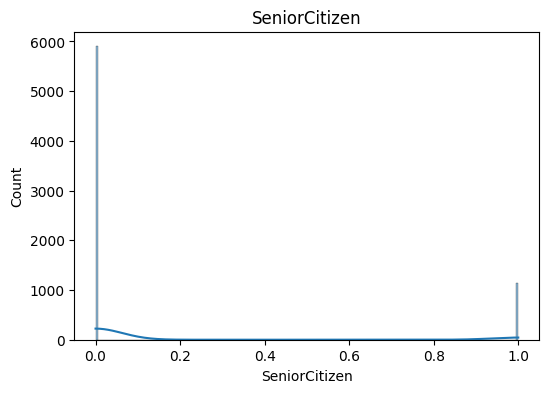

In [147]:
plt.figure(figsize=(6,4))

sns.histplot(df['SeniorCitizen'], kde=True)

plt.title("SeniorCitizen")
plt.show()

### Data Visualization
#### Histogram

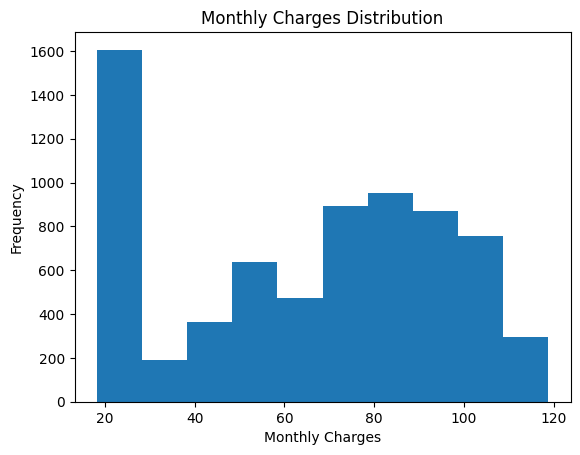

In [148]:
plt.hist(df['MonthlyCharges'])
plt.title("Monthly Charges Distribution")
plt.xlabel("Monthly Charges")
plt.ylabel("Frequency")
plt.show()

##### Interpretation:
The histogram visualized the distribution of monthly charges and helped identify skewness patterns.

#### Box Plot

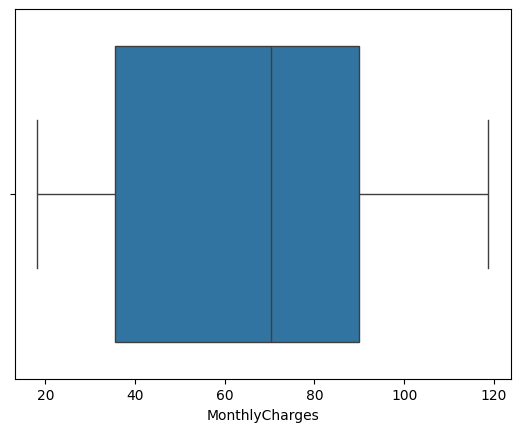

In [149]:
sns.boxplot(x=df['MonthlyCharges'])
plt.show()

##### Interpretation:
The boxplot helped identify outliers and understand the spread of monthly charges.

#### Count Plot

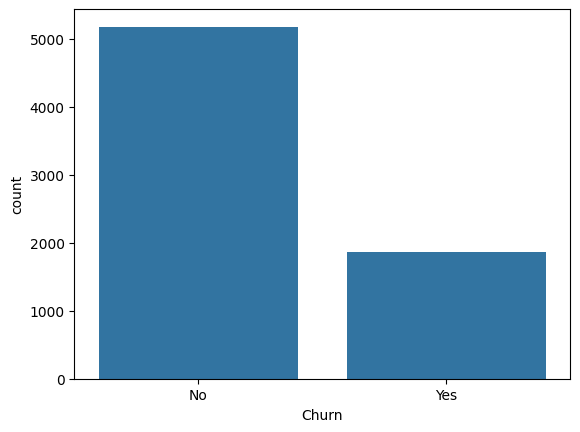

In [150]:
sns.countplot(x='Churn', data=df)
plt.show()

##### Interpretation:
The count plot showed the frequency of churn and non-churn customers in the dataset.

#### Scatter Plot

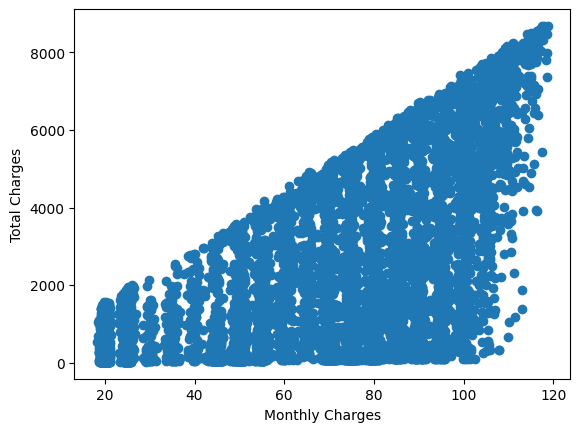

In [82]:
plt.scatter(df['MonthlyCharges'], df['TotalCharges'])

plt.xlabel("Monthly Charges")
plt.ylabel("Total Charges")
plt.show()

##### Interpretation:
The scatter plot examined the relationship between monthly charges and total charges.

#### Pair Plot

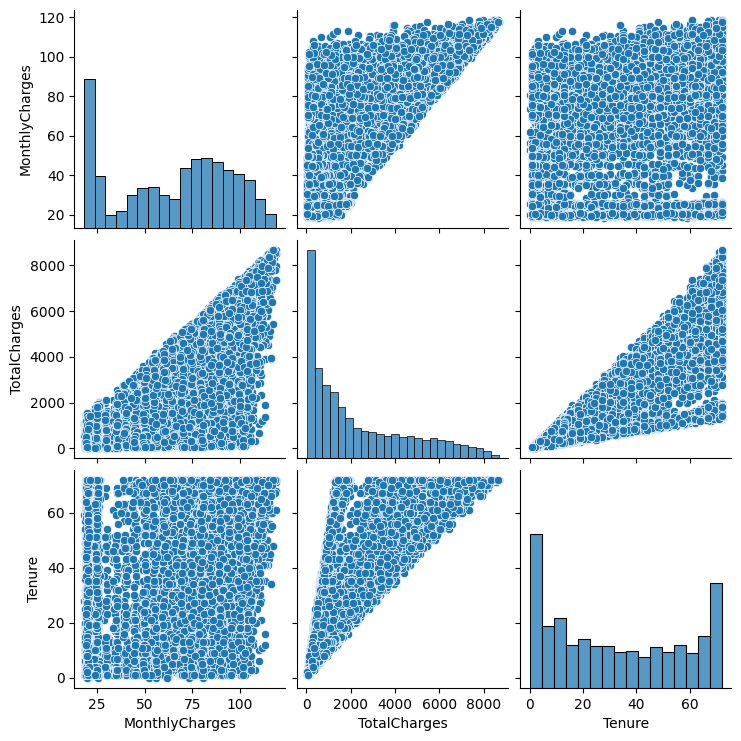

In [83]:
sns.pairplot(
    df[['MonthlyCharges','TotalCharges','Tenure']]
)

plt.show()

##### Interpretation:
The pair plot visualized pairwise relationships and distributions among numerical variables.

#### Heatmap

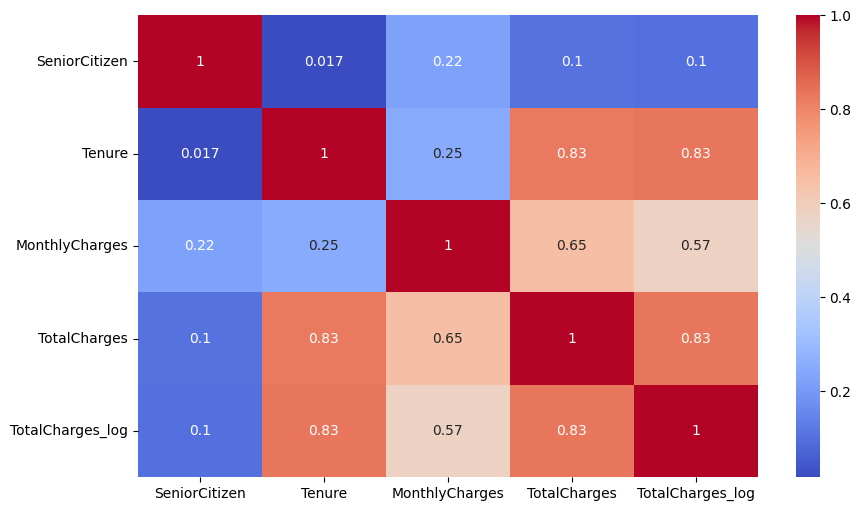

In [84]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.show()

##### Interpretation:
The heatmap displayed correlations among numerical variables and identified strongly related features.

#### OUTLIER DETECTION USING IQR

In [86]:
Q1 = df['MonthlyCharges'].quantile(0.25)
Q3 = df['MonthlyCharges'].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outlier = df[(df['MonthlyCharges'] >= lower_limit) & (df['MonthlyCharges'] <= upper_limit)]

In [87]:
outlier

,Customer_ID,gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_log
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,3.429137
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,7.544597
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,4.692723
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,7.518471
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,5.028148
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,7.596643
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,8.904345
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,5.850621
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,5.728800


##### Interpretation:
The Interquartile Range method was applied to identify and remove extreme values from MonthlyCharges.

#### OUTLIER DETECTION USING Z-SCORE

In [151]:
z_scores = zscore(df['MonthlyCharges'])

df = df[(np.abs(z_scores) < 3)]

In [152]:
df

,Customer_ID,gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,TotalCharges_log
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,3.429137
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,7.544597
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,4.692723
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,7.518471
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,5.028148
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No,7.596643
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No,8.904345
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No,5.850621
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes,5.728800


##### Interpretation:
Z-score analysis was used to detect values that significantly deviated from the mean.

#### LABEL ENCODING

In [153]:
le = LabelEncoder()

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:    
    df[col] = le.fit_transform(df[col])

C:\Users\Basavaraj\AppData\Local\Temp\ipykernel_24492\3062824321.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_columns = df.select_dtypes(include='object').columns


##### Interpretation:
Categorical variables were converted into numerical values to make them suitable for machine learning algorithms.

#### STANDARDIZATION

In [91]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df[['MonthlyCharges', 'TotalCharges']])

print(scaled_data)

[[-1.16032292 -0.99419409]
 [-0.25962894 -0.17373982]
 [-0.36266036 -0.95964911]
 ...
 [-1.1686319  -0.85451414]
 [ 0.32033821 -0.87209546]
 [ 1.35896134  2.01234407]]


##### Interpretation:
Standardization transformed numerical variables to have mean 0 and standard deviation 1.

#### NORMALIZATION

In [92]:
minmax = MinMaxScaler()

normalized_data = minmax.fit_transform(df[['MonthlyCharges', 'TotalCharges']])

print(normalized_data)

[[0.11542289 0.0012751 ]
 [0.38507463 0.21586661]
 [0.35422886 0.01031041]
 ...
 [0.11293532 0.03780868]
 [0.55870647 0.03321025]
 [0.86965174 0.78764136]]


##### Interpretation:
Normalization scaled feature values between 0 and 1 to improve model performance.

#### BIVARIATE ANALYSIS - CORRELATION

In [93]:
correlation = df.corr(numeric_only=True)

print(correlation)

                  Customer_ID    gender  SeniorCitizen   Partner  Dependents  \
Customer_ID          1.000000  0.006288      -0.002074 -0.026729   -0.012823   
gender               0.006288  1.000000      -0.001874 -0.001808    0.010517   
SeniorCitizen       -0.002074 -0.001874       1.000000  0.016479   -0.211185   
Partner             -0.026729 -0.001808       0.016479  1.000000    0.452676   
Dependents          -0.012823  0.010517      -0.211185  0.452676    1.000000   
Tenure               0.008035  0.005106       0.016567  0.379697    0.159712   
PhoneService        -0.006483 -0.006488       0.008576  0.017706   -0.001762   
MultipleLines        0.004316 -0.006739       0.146185  0.142410   -0.024991   
InternetService     -0.012407 -0.000863      -0.032310  0.000891    0.044590   
OnlineSecurity       0.013292 -0.015017      -0.128221  0.150828    0.152166   
OnlineBackup        -0.003334 -0.012057      -0.013632  0.153130    0.091015   
DeviceProtection    -0.006918  0.000549 

##### Interpretation:
Correlation analysis measured the strength and direction of relationships between variables.

####  CHI-SQUARE TEST

In [94]:
contingency_table = pd.crosstab(df['gender'],df['Churn'])

chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi Square Value:", chi2)

print("P Value:", p)

Chi Square Value: 0.4840828822091383
P Value: 0.48657873605618596


##### Interpretation:
The Chi-square test examined whether a significant association existed between gender and churn status.

#### ANOVA TEST

In [95]:
group1 = df[df['Churn'] == 0]['MonthlyCharges']

group2 = df[df['Churn'] == 1]['MonthlyCharges']

f_stat, p_val = f_oneway(group1,group2)

print("F Statistic:", f_stat)

print("P Value:", p_val)

F Statistic: 273.4637042077132
P Value: 2.706645606888272e-60


##### Interpretation:
ANOVA tested whether significant differences existed in monthly charges across churn categories.

#### FEATURE ENGINEERING

In [96]:
df['AverageCharge'] = (df['TotalCharges'] /(df['Tenure'] + 1))

print(df.head())

   Customer_ID  gender  SeniorCitizen  Partner  Dependents  Tenure  \
0         5375       0              0        1           0       1   
1         3962       1              0        0           0      34   
2         2564       1              0        0           0       2   
3         5535       1              0        0           0      45   
4         6511       0              0        0           0       2   

   PhoneService  MultipleLines  InternetService  OnlineSecurity  ...  \
0             0              1                0               0  ...   
1             1              0                0               2  ...   
2             1              0                0               2  ...   
3             0              1                0               2  ...   
4             1              0                1               0  ...   

   StreamingTV  StreamingMovies  Contract  PaperlessBilling  PaymentMethod  \
0            0                0         0                 1         

##### Interpretation:
A new feature named AverageCharge was created to capture customer spending behavior.

#### MULTICOLLINEARITY - VIF

In [98]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd
import numpy as np

# Select only numerical columns
X_vif = df[['MonthlyCharges','TotalCharges','Tenure']]

# Replace infinity values with NaN
X_vif = X_vif.replace([np.inf, -np.inf], np.nan)

# Fill missing values
X_vif = X_vif.fillna(X_vif.mean())

# Create VIF dataframe
vif_data = pd.DataFrame()

vif_data["Feature"] = X_vif.columns

vif_data["VIF"] = [
    variance_inflation_factor(
        X_vif.values,
        i
    )
    for i in range(X_vif.shape[1])
]

print(vif_data)

          Feature       VIF
0  MonthlyCharges  3.361520
1    TotalCharges  8.055643
2          Tenure  6.306042


##### Interpretation:
Variance Inflation Factor was used to identify multicollinearity among predictor variables.

#### PCA

In [100]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np

# Remove target column
X_pca = df.drop('Churn', axis=1)

# Keep only numerical columns
X_pca = X_pca.select_dtypes(include=np.number)

# Replace infinite values
X_pca = X_pca.replace([np.inf, -np.inf], np.nan)

# Fill missing values with mean
X_pca = X_pca.fillna(X_pca.mean())

# Standardize data before PCA
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_pca)

# Apply PCA
pca = PCA(n_components=2)

principal_components = pca.fit_transform(X_scaled)

# Create dataframe
pca_df = pd.DataFrame(
    principal_components,
    columns=['PC1','PC2']
)

print(pca_df.head())

        PC1       PC2
0 -3.369371 -0.228191
1 -0.988995  0.582009
2 -2.873391 -0.498478
3 -0.235532  1.745843
4 -3.065746 -1.600772


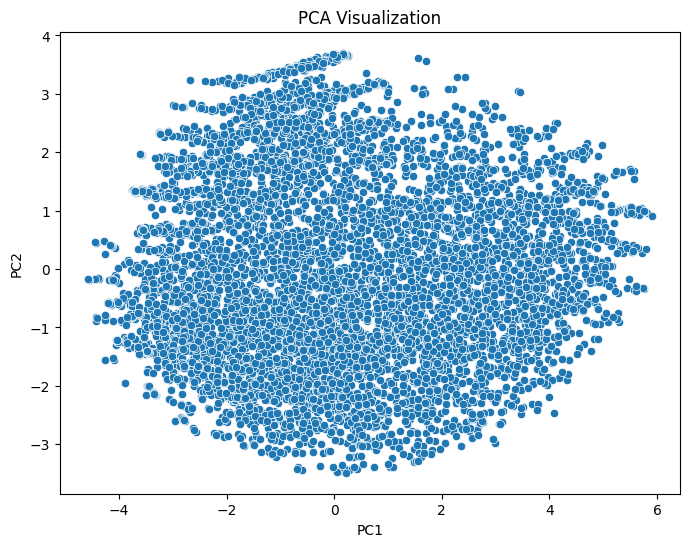

In [101]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x='PC1',
    y='PC2',
    data=pca_df
)

plt.title("PCA Visualization")

plt.show()

##### Interpretation:
Principal Component Analysis reduced dimensionality while preserving important information.

#### TRAIN TEST SPLIT

In [103]:
X = df.drop('Churn', axis=1)

y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

##### Interpretation:
The dataset was divided into training and testing subsets for model development and evaluation.

#### LOGISTIC REGRESSION

In [105]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# Features and target
X = df.drop('Churn', axis=1)
y = df['Churn']

# Keep only numerical columns
X = X.select_dtypes(include=np.number)

# Replace inf values
X = X.replace([np.inf, -np.inf], np.nan)

# Fill missing values
X = X.fillna(X.mean())

# Verify no missing values
print(X.isnull().sum())

# Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Logistic Regression
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_lr))

print(classification_report(y_test, pred_lr))

Customer_ID         0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
Tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
TotalCharges_log    0
AverageCharge       0
dtype: int64
Accuracy: 0.8126330731014905
              precision    recall  f1-score   support

           0       0.85      0.91      0.88      1036
           1       0.68      0.55      0.61       373

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.81      1409



C:\Users\Basavaraj\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


##### Interpretation:
Logistic Regression was implemented to predict customer churn based on independent variables.

#### DECISION TREE

In [106]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy")

print(accuracy_score(y_test, pred_dt))

Decision Tree Accuracy
0.7267565649396736


##### Interpretation:
A Decision Tree classifier was used to classify customers into churn and non-churn categories.

#### RANDOM FOREST

In [107]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

print("Random Forest Accuracy")

print(accuracy_score(y_test, pred_rf))

Random Forest Accuracy
0.794180269694819


##### Interpretation:
Random Forest combined multiple decision trees to improve prediction accuracy and reduce overfitting.

#### CONFUSION MATRIX

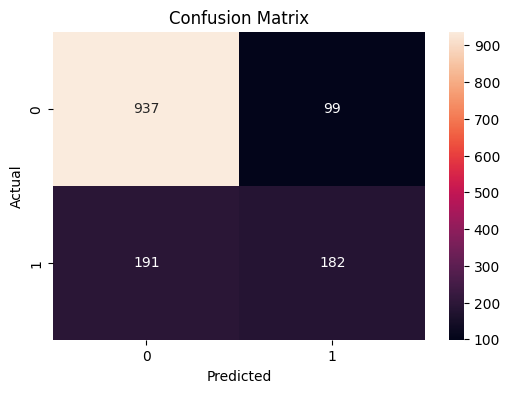

In [108]:
cm = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

##### Interpretation:
The confusion matrix evaluated model performance by comparing actual and predicted values.

#### FINAL CLEAN DATASET

In [109]:
print(df.head())

print(df.shape())

   Customer_ID  gender  SeniorCitizen  Partner  Dependents  Tenure  \
0         5375       0              0        1           0       1   
1         3962       1              0        0           0      34   
2         2564       1              0        0           0       2   
3         5535       1              0        0           0      45   
4         6511       0              0        0           0       2   

   PhoneService  MultipleLines  InternetService  OnlineSecurity  ...  \
0             0              1                0               0  ...   
1             1              0                0               2  ...   
2             1              0                0               2  ...   
3             0              1                0               2  ...   
4             1              0                1               0  ...   

   StreamingTV  StreamingMovies  Contract  PaperlessBilling  PaymentMethod  \
0            0                0         0                 1         

TypeError: 'tuple' object is not callable

##### Interpretation:
The final processed dataset was examined after all preprocessing steps were completed.

#### SAVE CLEANED DATASET

In [154]:
df.to_csv(
    "Cleaned_Telecom_Churn_Dataset.csv",
    index=False
)

print("Cleaned Dataset Saved Successfully")

Cleaned Dataset Saved Successfully


##### Interpretation:
The cleaned dataset was saved as a CSV file for future analysis and model implementation.

#### Conclusion:
The Telecom Customer Churn dataset underwent complete preprocessing including data cleaning, missing value handling, duplicate removal, outlier detection, encoding, scaling, feature engineering, and dimensionality reduction. Statistical and machine learning techniques were applied to analyze customer behavior and predict churn patterns effectively.